# Model Comparison Analysis

This notebook compares LLM outputs across different models, **using self-consistency data as context**.

## Key Insight

Cross-model agreement must be interpreted in the context of within-model consistency:

| Scenario | Self-Consistency | Cross-Model Agreement | Interpretation |
|----------|-----------------|----------------------|----------------|
| A | High (95%) | High (90%) | Robust task |
| B | High (95%) | Low (42%) | **Systematic model difference** |
| C | Low (50%) | Low (42%) | Inherent task ambiguity |

## Prerequisites

Run `self_consistency_experiments.ipynb` first to generate self-consistency results for all models.

## 1. Setup & Configuration

In [1]:
import json
import sys
import importlib
from pathlib import Path
from collections import Counter, defaultdict
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add repo root to path for imports
# This notebook is at: experiments/compare_models/self_consistency/model_comparison_analysis.ipynb
REPO_ROOT = Path('.').resolve().parent.parent.parent
sys.path.insert(0, str(REPO_ROOT))

# Notebook configuration
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# ============================================================================
# CONFIGURATION - Must match self_consistency_experiments.ipynb
# ============================================================================

TEST_SET_TAG = 'test_set_2025_11_26'
SAMPLE_SIZE = 100
RANDOM_SEED = 42
NUM_RUNS = 5

MODELS = [
    'openai/gpt-5',
    'bedrock/openai.gpt-oss-120b-1:0',
]

def model_slug(model_name):
    return model_name.replace('/', '_').replace(':', '_').replace('.', '_')

CALL_TYPES = [
    'instrument_validation',
    'wavelength_normalization',
    'physobs_normalization',
    'mission_selection',
    'instrument_selection',
    'detector_normalization',
    'time_normalization',
    'cadence_normalization',
    'mission_identification',
]

HANDLER_MAP = {
    'detector_normalization': 'DetectorNormalizationFreeTextV2Handler',
    'cadence_normalization': 'CadenceNormalizationFreeTextHandler',
    'physobs_normalization': 'PhysObsNormalizationFreeTextV2Handler',
    'wavelength_normalization': 'WavelengthNormalizationSimpleHandler',
    'time_normalization': 'TimeNormalizationHandler',
    'mission_identification': 'MissionIdentificationHandler',
    'mission_selection': 'MissionSelectionHandler',
    'instrument_selection': 'InstrumentSelectionHandler',
    'instrument_validation': 'InstrumentValidationHandler',
}

# Response keys for extracting comparable values from parsed responses
# For set tasks, this extracts a list; for single-value tasks, a scalar
RESPONSE_KEYS = {
    'detector_normalization': 'detector',
    'cadence_normalization': 'cadences',
    'physobs_normalization': 'physical_observable',
    'wavelength_normalization': 'wavelengths',
    'time_normalization': ('start_datetime', 'end_datetime'),  # FIXED: tuple of fields
    'mission_identification': 'mission_indices',
    'mission_selection': 'mission_indices',
    'instrument_selection': 'instrument_indices',
    'instrument_validation': 'validation_result',
}

# Task type classification for proper comparison and visualization
# - 'binary': Single yes/no or categorical response (Jaccard = 0 or 1)
# - 'single': Single complex value like time range (Jaccard = 0 or 1)  
# - 'set': List of values where partial overlap is meaningful (Jaccard = 0 to 1)
TASK_TYPES = {
    'instrument_validation': 'binary',
    'detector_normalization': 'single',
    'physobs_normalization': 'single',
    'time_normalization': 'single',
    'wavelength_normalization': 'set',
    'cadence_normalization': 'set',
    'mission_selection': 'set',
    'instrument_selection': 'set',
    'mission_identification': 'set',
}

RESULTS_DIR = Path('results')

# ============================================================================
# JACCARD SIMILARITY FUNCTION
# ============================================================================

def jaccard_similarity(set1, set2):
    """
    Calculate Jaccard similarity between two sets.
    
    Jaccard = |intersection| / |union|
    
    For single-value tasks (sets of 1 element):
    - Same value: Jaccard = 1.0
    - Different values: Jaccard = 0.0
    
    For set tasks:
    - Full overlap: Jaccard = 1.0
    - Partial overlap: 0 < Jaccard < 1
    - No overlap: Jaccard = 0.0
    """
    if not set1 and not set2:
        return 1.0  # Both empty = agreement
    if not set1 or not set2:
        return 0.0  # One empty, one not = no agreement
    
    intersection = len(set1 & set2)
    union = len(set1 | set2)
    
    return intersection / union if union > 0 else 0.0


# ============================================================================
# CONFIDENCE INTERVAL FUNCTIONS
# ============================================================================

def mean_confidence_interval(data, confidence=0.95):
    """
    Calculate confidence interval for the mean using t-distribution.
    
    Returns (mean, lower_bound, upper_bound, standard_error)
    """
    from scipy import stats
    
    data = np.array(data)
    n = len(data)
    if n < 2:
        return (np.mean(data), np.mean(data), np.mean(data), 0)
    
    mean = np.mean(data)
    se = stats.sem(data)  # Standard error of the mean
    
    # t-value for confidence level
    t_val = stats.t.ppf((1 + confidence) / 2, n - 1)
    margin = t_val * se
    
    return (mean, mean - margin, mean + margin, se)


def bootstrap_confidence_interval(data, n_bootstrap=1000, confidence=0.95):
    """
    Calculate bootstrap confidence interval for the mean.
    
    More robust for non-normal distributions (like Jaccard scores).
    """
    data = np.array(data)
    n = len(data)
    if n < 2:
        return (np.mean(data), np.mean(data), np.mean(data))
    
    # Bootstrap resampling
    rng = np.random.default_rng(42)  # Reproducible
    bootstrap_means = []
    for _ in range(n_bootstrap):
        sample = rng.choice(data, size=n, replace=True)
        bootstrap_means.append(np.mean(sample))
    
    # Percentile method
    alpha = (1 - confidence) / 2
    lower = np.percentile(bootstrap_means, alpha * 100)
    upper = np.percentile(bootstrap_means, (1 - alpha) * 100)
    
    return (np.mean(data), lower, upper)


def wilson_score_interval(successes, total, confidence=0.95):
    """
    Wilson score confidence interval for proportions.
    
    Better than normal approximation for extreme proportions or small samples.
    """
    from scipy import stats
    
    if total == 0:
        return (0, 0, 0)
    
    p = successes / total
    z = stats.norm.ppf((1 + confidence) / 2)
    
    denominator = 1 + z**2 / total
    center = (p + z**2 / (2 * total)) / denominator
    margin = z * np.sqrt((p * (1 - p) + z**2 / (4 * total)) / total) / denominator
    
    return (p, max(0, center - margin), min(1, center + margin))


def extract_comparable_value(parsed, call_type):
    """
    Extract a comparable value from parsed response based on call type.
    
    Returns a frozenset for Jaccard comparison.
    """
    if parsed is None:
        return frozenset(['PARSE_ERROR'])
    
    response_key = RESPONSE_KEYS.get(call_type)
    
    # Handle time_normalization specially (tuple of fields)
    if isinstance(response_key, tuple):
        # Extract multiple fields and combine into comparable tuple
        values = tuple(parsed.get(field) for field in response_key)
        return frozenset([values])
    
    # Standard extraction
    if isinstance(parsed, dict):
        response_val = parsed.get(response_key)
    else:
        response_val = parsed
    
    # Convert to frozenset for Jaccard
    if response_val is None:
        return frozenset(['NONE'])
    elif isinstance(response_val, (list, tuple)):
        # Set task: convert list to frozenset
        return frozenset(str(v) for v in response_val)
    else:
        # Single value task: wrap in frozenset
        return frozenset([str(response_val)])


print(f"Repo root: {REPO_ROOT}")
print(f"Test Set: {TEST_SET_TAG}")
print(f"Models: {len(MODELS)}")
for m in MODELS:
    print(f"  - {m}")
print(f"\nCall Types by Task Type:")
for task_type in ['binary', 'single', 'set']:
    tasks = [ct for ct, tt in TASK_TYPES.items() if tt == task_type]
    print(f"  {task_type}: {', '.join(tasks)}")

Repo root: /Users/abuonomo/code/nasa/paper-data-linking
Test Set: test_set_2025_11_26
Models: 2
  - openai/gpt-5
  - bedrock/openai.gpt-oss-120b-1:0

Call Types by Task Type:
  binary: instrument_validation
  single: detector_normalization, physobs_normalization, time_normalization
  set: wavelength_normalization, cadence_normalization, mission_selection, instrument_selection, mission_identification


## 2. Check Data Availability

In [2]:
# Check which models have complete self-consistency results
def check_data_availability():
    status = {}
    for model in MODELS:
        slug = model_slug(model)
        status[model] = {'complete': [], 'incomplete': []}
        
        for call_type in CALL_TYPES:
            runs_found = 0
            for run in range(1, NUM_RUNS + 1):
                exp_dir = RESULTS_DIR / TEST_SET_TAG / slug / call_type / f"run{run}"
                if exp_dir.exists() and list(exp_dir.glob('*.jsonl')):
                    runs_found += 1
            
            if runs_found >= NUM_RUNS:
                status[model]['complete'].append(call_type)
            else:
                status[model]['incomplete'].append((call_type, runs_found))
    
    return status

data_status = check_data_availability()

print("Data Availability:")
print("="*60)
all_ready = True
for model in MODELS:
    complete = len(data_status[model]['complete'])
    incomplete = len(data_status[model]['incomplete'])
    
    if incomplete > 0:
        all_ready = False
        print(f"\n{model}:")
        print(f"  Complete: {complete}/{len(CALL_TYPES)}")
        print(f"  Missing:")
        for ct, runs in data_status[model]['incomplete']:
            print(f"    - {ct}: {runs}/{NUM_RUNS} runs")
    else:
        print(f"\n{model}: All {complete} call types complete")

if all_ready:
    print("\n" + "="*60)
    print("Ready for cross-model comparison!")
else:
    print("\n" + "="*60)
    print("Run self_consistency_experiments.ipynb first to complete missing experiments.")

Data Availability:

openai/gpt-5: All 9 call types complete

bedrock/openai.gpt-oss-120b-1:0: All 9 call types complete

Ready for cross-model comparison!


## 3. Load Self-Consistency Results

In [3]:
def load_handler(call_type):
    handler_class_name = HANDLER_MAP[call_type]
    handlers_module = importlib.import_module('experiments.compare_models.handlers')
    handler_class = getattr(handlers_module, handler_class_name)
    return handler_class()

def load_model_results(model, call_type):
    """
    Load results for a model/call_type and compute Jaccard-based consistency.
    
    Returns per-case responses as frozensets for Jaccard comparison,
    plus case-level Jaccards for confidence interval calculation.
    """
    handler = load_handler(call_type)
    slug = model_slug(model)
    
    all_cases = defaultdict(lambda: {'response_sets': [], 'raw_outputs': []})
    
    for run in range(1, NUM_RUNS + 1):
        exp_dir = RESULTS_DIR / TEST_SET_TAG / slug / call_type / f"run{run}"
        jsonl_files = list(exp_dir.glob('*.jsonl'))
        
        if not jsonl_files:
            continue
        
        with open(jsonl_files[0]) as f:
            for line in f:
                data = json.loads(line)
                case_id = data.get('original_id', data.get('case_index'))
                output_content = data.get('output_content', '')
                
                try:
                    parsed = handler.parse_response(output_content)
                except:
                    parsed = None
                
                # Extract comparable frozenset
                response_set = extract_comparable_value(parsed, call_type)
                
                all_cases[case_id]['response_sets'].append(response_set)
                all_cases[case_id]['raw_outputs'].append(output_content[:200])
    
    # Calculate Jaccard-based self-consistency
    # For each case, compute mean pairwise Jaccard across all runs
    total = len(all_cases)
    case_jaccards = []  # Store for CI calculation
    perfect_count = 0
    
    for case_id, info in all_cases.items():
        response_sets = info['response_sets']
        
        if len(response_sets) < 2:
            info['mean_jaccard'] = 1.0 if response_sets else 0.0
            info['majority_set'] = response_sets[0] if response_sets else frozenset()
            if response_sets:
                case_jaccards.append(1.0)
            continue
        
        # Compute pairwise Jaccard similarities
        pairwise_jaccards = []
        for i in range(len(response_sets)):
            for j in range(i + 1, len(response_sets)):
                pairwise_jaccards.append(jaccard_similarity(response_sets[i], response_sets[j]))
        
        mean_jaccard = sum(pairwise_jaccards) / len(pairwise_jaccards) if pairwise_jaccards else 1.0
        info['mean_jaccard'] = mean_jaccard
        case_jaccards.append(mean_jaccard)
        
        # Check for perfect agreement (all identical)
        if all(rs == response_sets[0] for rs in response_sets):
            perfect_count += 1
        
        # Compute "majority" response (most common set)
        set_counts = Counter(tuple(sorted(rs)) for rs in response_sets)
        most_common_tuple = set_counts.most_common(1)[0][0]
        info['majority_set'] = frozenset(most_common_tuple)
    
    # Overall metrics with confidence intervals
    mean_self_consistency = (sum(case_jaccards) / len(case_jaccards) * 100) if case_jaccards else 0
    perfect_rate = (perfect_count / total * 100) if total > 0 else 0
    
    # Compute 95% CI using bootstrap (more robust for bounded [0,1] data)
    if case_jaccards:
        _, ci_lower, ci_upper = bootstrap_confidence_interval(case_jaccards)
        ci_lower *= 100  # Convert to percentage
        ci_upper *= 100
    else:
        ci_lower, ci_upper = 0, 0
    
    return {
        'cases': dict(all_cases),
        'total': total,
        'perfect_count': perfect_count,
        'perfect_rate': perfect_rate,
        'mean_jaccard': mean_self_consistency,  # As percentage
        'case_jaccards': case_jaccards,  # Raw values for further analysis
        'ci_lower': ci_lower,  # 95% CI lower bound (%)
        'ci_upper': ci_upper,  # 95% CI upper bound (%)
        'task_type': TASK_TYPES[call_type],
    }

# Load all results
all_results = {}
for model in MODELS:
    all_results[model] = {}
    print(f"\nLoading {model}...")
    
    for call_type in CALL_TYPES:
        result = load_model_results(model, call_type)
        all_results[model][call_type] = result
        
        task_type = TASK_TYPES[call_type]
        marker = '*' if task_type == 'set' else ''  # Mark set tasks
        
        if result['total'] > 0:
            ci_width = result['ci_upper'] - result['ci_lower']
            print(f"  {call_type}{marker}: {result['mean_jaccard']:.0f}% [{result['ci_lower']:.0f}-{result['ci_upper']:.0f}%] (±{ci_width/2:.1f}%)")

print("\n" + "="*60)
print("* = set task (Jaccard captures partial overlap)")
print("Values shown as: mean [95% CI]")
print("="*60)
print("\nLoaded results for all models.")


Loading openai/gpt-5...


/Users/abuonomo/code/nasa/paper-data-linking/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  instrument_validation: 99% [97-100%] (±1.4%)
  wavelength_normalization*: 100% [100-100%] (±0.0%)
  physobs_normalization: 89% [85-93%] (±4.2%)
  mission_selection*: 96% [93-98%] (±2.9%)
  instrument_selection*: 98% [96-99%] (±1.5%)
  detector_normalization: 96% [93-98%] (±2.6%)
  time_normalization: 91% [86-95%] (±4.3%)
  cadence_normalization*: 100% [100-100%] (±0.0%)
  mission_identification*: 69% [64-74%] (±5.1%)

Loading bedrock/openai.gpt-oss-120b-1:0...
  instrument_validation: 97% [94-99%] (±2.4%)
  wavelength_normalization*: 100% [99-100%] (±0.6%)
  physobs_normalization: 83% [78-88%] (±5.0%)
  mission_selection*: 92% [87-95%] (±4.1%)
  instrument_selection*: 96% [93-98%] (±2.6%)
  detector_normalization: 99% [97-100%] (±1.4%)
  time_normalization: 92% [89-95%] (±3.4%)
  cadence_normalization*: 99% [98-100%] (±1.0%)
  mission_identification*: 90% [86-93%] (±3.8%)

* = set task (Jaccard captures partial overlap)
Values shown as: mean [95% CI]

Loaded results for all models.


## 4. Calculate Cross-Model Agreement

In [4]:
def calculate_cross_model_agreement(model1, model2, call_type, method='pairwise'):
    """
    Calculate Jaccard-based agreement between two models.
    
    Methods:
    - 'pairwise': Compare ALL runs from model1 with ALL runs from model2 (5×5=25 comparisons per case)
                  More statistically principled, uses all available data.
    - 'majority': Compare majority votes only (original method, 1 comparison per case)
    
    Returns case-level Jaccards for confidence interval calculation.
    """
    results1 = all_results[model1][call_type]
    results2 = all_results[model2][call_type]
    
    cases1 = results1['cases']
    cases2 = results2['cases']
    
    # Find common cases
    common_cases = set(cases1.keys()) & set(cases2.keys())
    
    if not common_cases:
        return None
    
    case_jaccards = []  # Mean Jaccard per case (for CI calculation)
    all_pairwise_jaccards = []  # All individual pairwise comparisons
    perfect_agree = 0
    disagree_cases = []
    
    for case_id in common_cases:
        sets1 = cases1[case_id].get('response_sets', [])
        sets2 = cases2[case_id].get('response_sets', [])
        
        if not sets1 or not sets2:
            continue
        
        if method == 'pairwise':
            # Compare ALL runs from model1 with ALL runs from model2
            pairwise_jaccards = []
            for s1 in sets1:
                for s2 in sets2:
                    j = jaccard_similarity(s1, s2)
                    pairwise_jaccards.append(j)
                    all_pairwise_jaccards.append(j)
            
            # Mean Jaccard for this case (across all 5×5=25 comparisons)
            case_mean_jaccard = np.mean(pairwise_jaccards)
            case_jaccards.append(case_mean_jaccard)
            
            # Perfect agreement = all pairwise comparisons are 1.0
            if case_mean_jaccard == 1.0:
                perfect_agree += 1
            else:
                # Get majority sets for reporting disagreements
                set1_majority = cases1[case_id].get('majority_set', frozenset())
                set2_majority = cases2[case_id].get('majority_set', frozenset())
                disagree_cases.append({
                    'case_id': case_id,
                    'model1_set': set1_majority,
                    'model2_set': set2_majority,
                    'jaccard': case_mean_jaccard,  # Mean pairwise Jaccard
                    'pairwise_std': np.std(pairwise_jaccards),  # Variance in pairwise comparisons
                    'model1_responses': [tuple(sorted(rs)) for rs in sets1],
                    'model2_responses': [tuple(sorted(rs)) for rs in sets2],
                })
        
        else:  # method == 'majority'
            set1 = cases1[case_id].get('majority_set', frozenset())
            set2 = cases2[case_id].get('majority_set', frozenset())
            
            jaccard = jaccard_similarity(set1, set2)
            case_jaccards.append(jaccard)
            all_pairwise_jaccards.append(jaccard)
            
            if jaccard == 1.0:
                perfect_agree += 1
            else:
                disagree_cases.append({
                    'case_id': case_id,
                    'model1_set': set1,
                    'model2_set': set2,
                    'jaccard': jaccard,
                    'model1_responses': [tuple(sorted(rs)) for rs in sets1],
                    'model2_responses': [tuple(sorted(rs)) for rs in sets2],
                })
    
    mean_jaccard = np.mean(case_jaccards) * 100 if case_jaccards else 0
    perfect_rate = perfect_agree / len(common_cases) * 100 if common_cases else 0
    
    # Compute 95% CI using bootstrap on case-level means
    if case_jaccards:
        _, ci_lower, ci_upper = bootstrap_confidence_interval(case_jaccards)
        ci_lower *= 100
        ci_upper *= 100
    else:
        ci_lower, ci_upper = 0, 0
    
    return {
        'total': len(common_cases),
        'perfect_agree': perfect_agree,
        'perfect_rate': perfect_rate,
        'mean_jaccard': mean_jaccard,
        'case_jaccards': case_jaccards,
        'all_pairwise_jaccards': all_pairwise_jaccards,  # All 25×N comparisons
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'method': method,
        'n_pairwise_per_case': NUM_RUNS * NUM_RUNS,  # 25 for 5 runs
        'disagreements': sorted(disagree_cases, key=lambda x: x['jaccard']),
    }

# Calculate cross-model agreement for all pairs using PAIRWISE method
cross_model_results = {}
model_pairs = list(combinations(MODELS, 2))

print(f"Calculating cross-model agreement using ALL PAIRWISE comparisons...")
print(f"(5 runs × 5 runs = 25 comparisons per case)\n")

for call_type in CALL_TYPES:
    cross_model_results[call_type] = {}
    task_type = TASK_TYPES[call_type]
    marker = '*' if task_type == 'set' else ''
    
    for model1, model2 in model_pairs:
        pair_name = f"{model_slug(model1)[:15]} vs {model_slug(model2)[:15]}"
        result = calculate_cross_model_agreement(model1, model2, call_type, method='pairwise')
        cross_model_results[call_type][pair_name] = result
        
        if result:
            ci_width = result['ci_upper'] - result['ci_lower']
            n_comparisons = result['total'] * result['n_pairwise_per_case']
            print(f"{call_type}{marker}: {result['mean_jaccard']:.0f}% [{result['ci_lower']:.0f}-{result['ci_upper']:.0f}%] ({n_comparisons} pairwise comparisons)")
        else:
            print(f"{call_type}{marker}: N/A")

print("\n" + "="*60)
print("* = set task (Jaccard captures partial overlap)")
print("Method: All pairwise (25 comparisons per case)")
print("="*60)

Calculating cross-model agreement using ALL PAIRWISE comparisons...
(5 runs × 5 runs = 25 comparisons per case)

instrument_validation: 97% [95-99%] (2500 pairwise comparisons)
wavelength_normalization*: 100% [99-100%] (2500 pairwise comparisons)
physobs_normalization: 79% [73-86%] (2500 pairwise comparisons)
mission_selection*: 89% [84-93%] (2500 pairwise comparisons)
instrument_selection*: 92% [88-96%] (2500 pairwise comparisons)
detector_normalization: 96% [92-98%] (2500 pairwise comparisons)
time_normalization: 87% [81-92%] (2500 pairwise comparisons)
cadence_normalization*: 99% [98-100%] (2500 pairwise comparisons)
mission_identification*: 50% [43-57%] (2500 pairwise comparisons)

* = set task (Jaccard captures partial overlap)
Method: All pairwise (25 comparisons per case)


## 5. Variance Decomposition

In [11]:
# Create variance decomposition table with Jaccard metrics
decomposition = []

for call_type in CALL_TYPES:
    task_type = TASK_TYPES[call_type]
    type_marker = {'binary': '○', 'single': '◐', 'set': '●'}[task_type]
    
    row = {
        'Call Type': f"{call_type} {type_marker}",
        'Type': task_type,
    }
    
    # Self-consistency (mean Jaccard) for each model
    for model in MODELS:
        slug = model_slug(model)[:12]
        mj = all_results[model][call_type]['mean_jaccard']
        pf = all_results[model][call_type]['perfect_rate']
        row[f'{slug} SC'] = f"{mj:.0f}%"
        row[f'{slug} Perf'] = f"{pf:.0f}%"
    
    # Cross-model agreement (mean Jaccard)
    for pair_name, result in cross_model_results[call_type].items():
        if result:
            row['Cross-Model'] = f"{result['mean_jaccard']:.0f}%"
            row['Cross Perfect'] = f"{result['perfect_rate']:.0f}%"
        else:
            row['Cross-Model'] = 'N/A'
            row['Cross Perfect'] = 'N/A'
    
    # Interpretation based on Jaccard values
    avg_sc = sum(all_results[m][call_type]['mean_jaccard'] for m in MODELS) / len(MODELS)
    cross_result = list(cross_model_results[call_type].values())[0]
    cross_jaccard = cross_result['mean_jaccard'] if cross_result else 0
    
    if avg_sc >= 90 and cross_jaccard >= 85:
        row['Status'] = '✅ Robust'
    elif avg_sc >= 90 and cross_jaccard < 85:
        row['Status'] = '⚠️ Bias'
    elif avg_sc < 90 and cross_jaccard < 85:
        row['Status'] = '❌ Ambiguous'
    else:
        row['Status'] = '📊 Moderate'
    
    decomposition.append(row)

df_decomp = pd.DataFrame(decomposition)

print("\n" + "="*140)
print("VARIANCE DECOMPOSITION: Self-Consistency vs Cross-Model Agreement (Jaccard Similarity)")
print("="*140)
print(df_decomp.to_string(index=False))
print("\n" + "="*140)
print("Legend:")
print("  Task Types: ○ = binary (exact match), ◐ = single value, ● = set (partial overlap captured)")
print("  SC = Self-Consistency (mean pairwise Jaccard across 5 runs)")
print("  Perf = Perfect agreement rate (all 5 runs identical)")
print("  Cross-Model = Mean Jaccard between model majority votes")
print("\nInterpretation:")
print("  ✅ Robust = High SC + High Cross-Model (task works well)")
print("  ⚠️ Bias = High SC + Low Cross-Model (models interpret differently)")
print("  ❌ Ambiguous = Low SC + Low Cross-Model (task needs redesign)")
print("  📊 Moderate = Mixed results")


VARIANCE DECOMPOSITION: Self-Consistency vs Cross-Model Agreement (Jaccard Similarity)
                 Call Type   Type openai_gpt-5 SC openai_gpt-5 Perf bedrock_open SC bedrock_open Perf Cross-Model Cross Perfect      Status
   instrument_validation ○ binary             99%               97%             97%               93%         97%           91%    ✅ Robust
wavelength_normalization ●    set            100%              100%            100%               99%        100%           99%    ✅ Robust
   physobs_normalization ◐ single             89%               77%             83%               67%         79%           64% ❌ Ambiguous
       mission_selection ●    set             96%               90%             92%               81%         89%           76%    ✅ Robust
    instrument_selection ●    set             98%               93%             96%               90%         92%           83%    ✅ Robust
  detector_normalization ◐ single             96%               92%     

## 5b. Cost Analysis

Analyze the cost of running these self-consistency experiments.

In [12]:
# Cost Analysis
# Load token counts and costs from all results

# Pricing per 1M tokens (from OpenAI/Bedrock pricing pages)
MODEL_PRICING = {
    'openai/gpt-5': {
        'input': 1.25,    # $1.25/1M input tokens
        'output': 10.00,  # $10.00/1M output tokens
    },
    'bedrock/openai.gpt-oss-120b-1:0': {
        # Bedrock pricing: $0.00015/1K input, $0.0006/1K output
        'input': 0.15,    # $0.15/1M input tokens
        'output': 0.60,   # $0.60/1M output tokens
    },
}

def load_cost_data():
    """Load token counts and calculate costs from all result files."""
    cost_data = []
    
    for model in MODELS:
        slug = model_slug(model)
        pricing = MODEL_PRICING.get(model, {'input': 0, 'output': 0})
        
        for call_type in CALL_TYPES:
            for run in range(1, NUM_RUNS + 1):
                exp_dir = RESULTS_DIR / TEST_SET_TAG / slug / call_type / f"run{run}"
                jsonl_files = list(exp_dir.glob('*.jsonl'))
                
                if not jsonl_files:
                    continue
                
                with open(jsonl_files[0]) as f:
                    for line in f:
                        data = json.loads(line)
                        
                        prompt_tokens = data.get('prompt_tokens', 0)
                        completion_tokens = data.get('completion_tokens', 0)
                        
                        # Calculate cost from pricing (more accurate than pre-calculated)
                        cost = (prompt_tokens * pricing['input'] / 1_000_000 + 
                               completion_tokens * pricing['output'] / 1_000_000)
                        
                        cost_data.append({
                            'model': model,
                            'call_type': call_type,
                            'run': run,
                            'prompt_tokens': prompt_tokens,
                            'completion_tokens': completion_tokens,
                            'total_tokens': prompt_tokens + completion_tokens,
                            'cost_usd': cost,
                        })
    
    return pd.DataFrame(cost_data)

# Load cost data
df_costs = load_cost_data()

print(f"Loaded {len(df_costs):,} result records with cost data\n")

# Summary by model
print("="*80)
print("COST SUMMARY BY MODEL")
print("="*80)
model_summary = df_costs.groupby('model').agg({
    'prompt_tokens': 'sum',
    'completion_tokens': 'sum',
    'total_tokens': 'sum',
    'cost_usd': 'sum'
}).round(4)
model_summary['cost_usd'] = model_summary['cost_usd'].apply(lambda x: f"${x:.2f}")
model_summary['total_tokens'] = model_summary['total_tokens'].apply(lambda x: f"{x:,.0f}")
print(model_summary)

# Summary by call type
print("\n" + "="*80)
print("COST SUMMARY BY CALL TYPE (both models combined)")
print("="*80)
call_type_summary = df_costs.groupby('call_type').agg({
    'prompt_tokens': 'sum',
    'completion_tokens': 'sum', 
    'cost_usd': 'sum'
}).sort_values('cost_usd', ascending=False)

call_type_summary['avg_prompt'] = (call_type_summary['prompt_tokens'] / (len(MODELS) * NUM_RUNS * SAMPLE_SIZE)).astype(int)
call_type_summary['avg_completion'] = (call_type_summary['completion_tokens'] / (len(MODELS) * NUM_RUNS * SAMPLE_SIZE)).astype(int)
call_type_summary['cost_usd'] = call_type_summary['cost_usd'].apply(lambda x: f"${x:.2f}")
print(call_type_summary[['avg_prompt', 'avg_completion', 'cost_usd']])

# Total cost
total_cost = df_costs['cost_usd'].sum()
total_tokens = df_costs['total_tokens'].sum()
print(f"\n{'='*80}")
print(f"TOTAL EXPERIMENT COST")
print(f"{'='*80}")
print(f"Total tokens: {total_tokens:,.0f}")
print(f"Total cost: ${total_cost:.2f}")
print(f"\nBreakdown:")
print(f"  - {len(MODELS)} models × {len(CALL_TYPES)} call types × {NUM_RUNS} runs × {SAMPLE_SIZE} cases")
print(f"  - = {len(MODELS) * len(CALL_TYPES) * NUM_RUNS * SAMPLE_SIZE:,} total LLM calls")
print(f"  - Average cost per call: ${total_cost / len(df_costs):.4f}")

# Cost comparison
print(f"\nModel cost comparison:")
for model in MODELS:
    model_cost = df_costs[df_costs['model'] == model]['cost_usd'].sum()
    print(f"  - {model}: ${model_cost:.2f}")
gpt5_cost = df_costs[df_costs['model'] == 'openai/gpt-5']['cost_usd'].sum()
bedrock_cost = df_costs[df_costs['model'] == 'bedrock/openai.gpt-oss-120b-1:0']['cost_usd'].sum()
if bedrock_cost > 0:
    print(f"\nGPT-5 is {gpt5_cost/bedrock_cost:.1f}x more expensive than Bedrock GPT-OSS-120B")

Loaded 9,000 result records with cost data

COST SUMMARY BY MODEL
                                 prompt_tokens  completion_tokens  \
model                                                               
bedrock/openai.gpt-oss-120b-1:0        7126943            1026981   
openai/gpt-5                           6674800            3351759   

                                total_tokens cost_usd  
model                                                  
bedrock/openai.gpt-oss-120b-1:0    8,153,924    $1.69  
openai/gpt-5                      10,026,559   $41.86  

COST SUMMARY BY CALL TYPE (both models combined)
                          avg_prompt  avg_completion cost_usd
call_type                                                    
mission_identification          5138            1614   $18.18
instrument_validation           1705             701    $5.58
time_normalization               670             614    $4.86
mission_selection                956             388    $3.56
instrument_

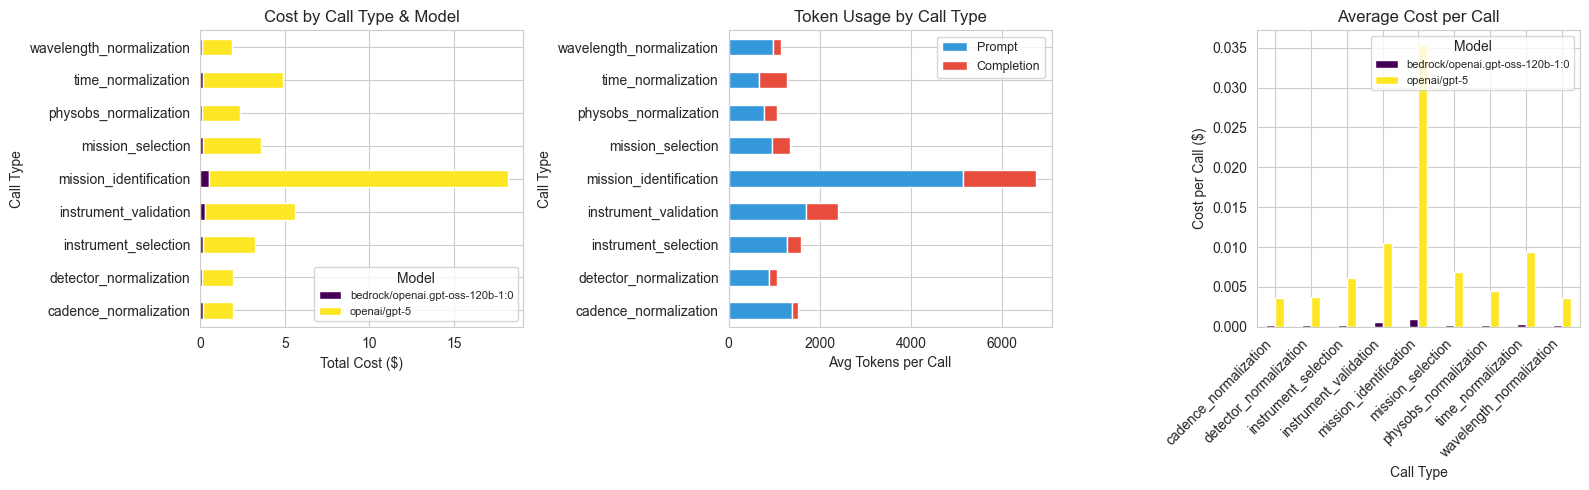


COST EFFICIENCY ANALYSIS

Cost per 1% of cross-model agreement (lower = more efficient):
--------------------------------------------------------------------------------
wavelength_normalization     $1.89 / 100% = $0.019 per %
cadence_normalization        $1.92 / 99% = $0.019 per %
detector_normalization       $1.95 / 96% = $0.020 per %
physobs_normalization        $2.37 / 79% = $0.030 per %
instrument_selection         $3.21 / 92% = $0.035 per %
mission_selection            $3.56 / 89% = $0.040 per %
time_normalization           $4.86 / 87% = $0.056 per %
instrument_validation        $5.58 / 97% = $0.057 per %
mission_identification       $18.18 / 50% = $0.362 per %


In [13]:
# Cost visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Cost by call type (stacked by model)
ax1 = axes[0]
cost_by_type_model = df_costs.groupby(['call_type', 'model'])['cost_usd'].sum().unstack()
cost_by_type_model.plot(kind='barh', stacked=True, ax=ax1, colormap='viridis')
ax1.set_xlabel('Total Cost ($)')
ax1.set_ylabel('Call Type')
ax1.set_title('Cost by Call Type & Model')
ax1.legend(title='Model', fontsize=8, loc='lower right')

# 2. Tokens by call type
ax2 = axes[1]
tokens_by_type = df_costs.groupby('call_type').agg({
    'prompt_tokens': 'mean',
    'completion_tokens': 'mean'
})
tokens_by_type.plot(kind='barh', stacked=True, ax=ax2, color=['#3498db', '#e74c3c'])
ax2.set_xlabel('Avg Tokens per Call')
ax2.set_ylabel('Call Type')
ax2.set_title('Token Usage by Call Type')
ax2.legend(['Prompt', 'Completion'], fontsize=9)

# 3. Cost per call by model and call type
ax3 = axes[2]
cost_per_call = df_costs.groupby(['call_type', 'model'])['cost_usd'].mean().unstack()
cost_per_call.plot(kind='bar', ax=ax3, colormap='viridis')
ax3.set_xlabel('Call Type')
ax3.set_ylabel('Cost per Call ($)')
ax3.set_title('Average Cost per Call')
ax3.legend(title='Model', fontsize=8)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Cost efficiency analysis
print("\n" + "="*80)
print("COST EFFICIENCY ANALYSIS")
print("="*80)
print("\nCost per 1% of cross-model agreement (lower = more efficient):")
print("-"*80)

efficiency_data = []
for call_type in CALL_TYPES:
    cost = df_costs[df_costs['call_type'] == call_type]['cost_usd'].sum()
    cross_result = list(cross_model_results[call_type].values())[0]
    agreement = cross_result['mean_jaccard'] if cross_result else 0
    
    cost_per_pct = cost / agreement if agreement > 0 else float('inf')
    
    efficiency_data.append({
        'call_type': call_type,
        'total_cost': cost,
        'agreement': agreement,
        'cost_per_pct': cost_per_pct
    })

df_efficiency = pd.DataFrame(efficiency_data).sort_values('cost_per_pct')
for _, row in df_efficiency.iterrows():
    print(f"{row['call_type']:<28} ${row['total_cost']:.2f} / {row['agreement']:.0f}% = ${row['cost_per_pct']:.3f} per %")

## 6. Visualization

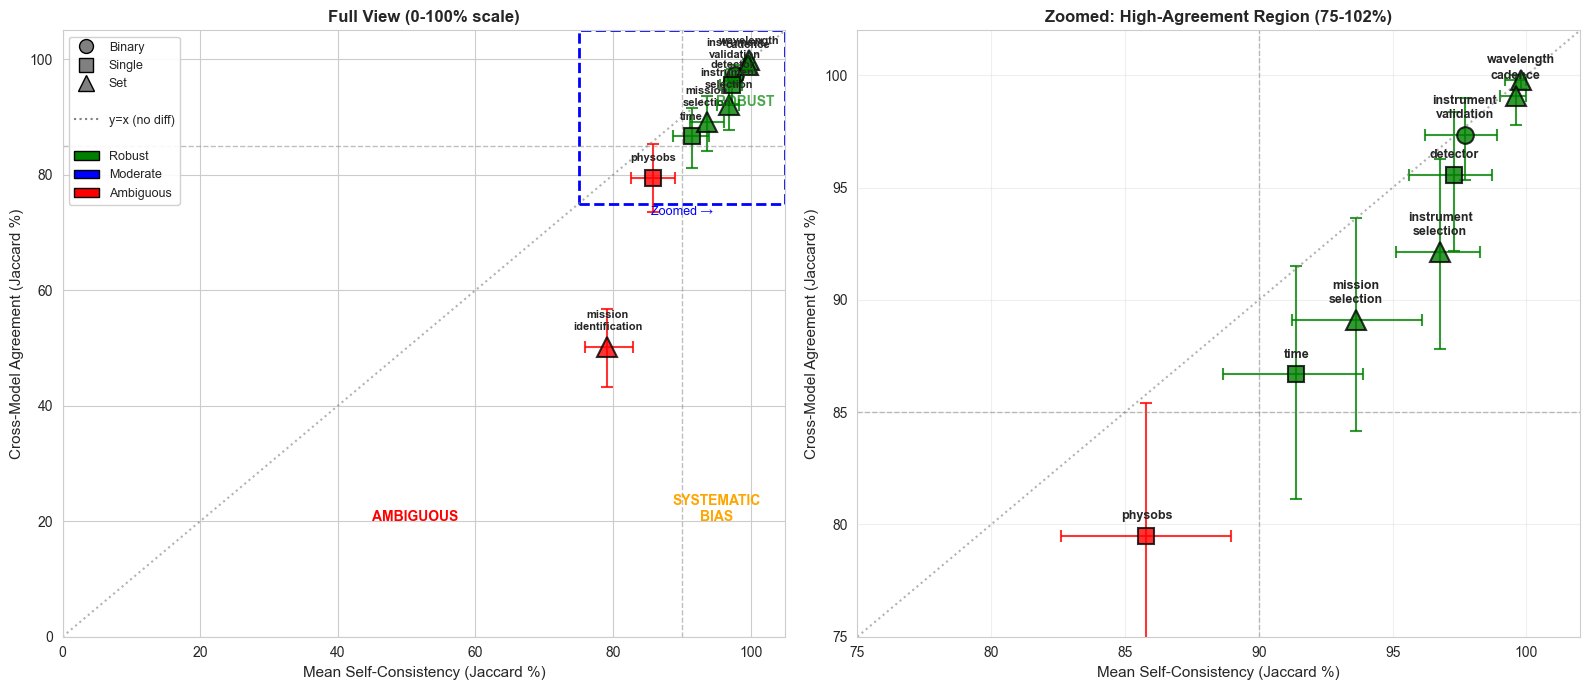


95% CONFIDENCE INTERVAL SUMMARY (All Pairwise Method)
Call Type                    Type     Self-Consistency       Cross-Model           
------------------------------------------------------------------------------------------
wavelength_normalization     set      100% [99-100]          100% [99-100]         
cadence_normalization        set      100% [99-100]          99% [98-100]          
instrument_validation        binary   98% [96-99]            97% [95-99]           
detector_normalization       single   97% [96-99]            96% [92-98]           
instrument_selection         set      97% [95-98]            92% [88-96]           
mission_selection            set      94% [91-96]            89% [84-94]           
time_normalization           single   91% [89-94]            87% [81-92]           
physobs_normalization        single   86% [83-89]            79% [74-85]           
mission_identification       set      79% [76-83]            50% [43-57]           


In [14]:
# Scatter plot: Self-Consistency vs Cross-Model Agreement (Jaccard) WITH ERROR BARS
# Two-panel layout: full view (honest 0-100% scale) + zoomed view of clustered region

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Prepare data with confidence intervals
plot_data = []
for call_type in CALL_TYPES:
    task_type = TASK_TYPES[call_type]
    
    # Average self-consistency (mean Jaccard) across models with CI
    model_jaccards = [all_results[m][call_type]['mean_jaccard'] for m in MODELS]
    avg_sc = np.mean(model_jaccards)
    
    # For SC error bars: combine case_jaccards from both models
    all_sc_jaccards = []
    for m in MODELS:
        all_sc_jaccards.extend(all_results[m][call_type].get('case_jaccards', []))
    if all_sc_jaccards:
        _, sc_ci_lower, sc_ci_upper = bootstrap_confidence_interval(all_sc_jaccards)
        sc_ci_lower *= 100
        sc_ci_upper *= 100
    else:
        sc_ci_lower, sc_ci_upper = avg_sc, avg_sc
    
    # Cross-model agreement (mean Jaccard) with CI
    cross_result = list(cross_model_results[call_type].values())[0]
    cross_jaccard = cross_result['mean_jaccard'] if cross_result else 0
    cross_ci_lower = cross_result['ci_lower'] if cross_result else 0
    cross_ci_upper = cross_result['ci_upper'] if cross_result else 0
    n_disagree = len(cross_result['disagreements']) if cross_result else 0
    
    plot_data.append({
        'call_type': call_type,
        'task_type': task_type,
        'self_consistency': avg_sc,
        'sc_ci_lower': sc_ci_lower,
        'sc_ci_upper': sc_ci_upper,
        'cross_model': cross_jaccard,
        'cross_ci_lower': cross_ci_lower,
        'cross_ci_upper': cross_ci_upper,
        'disagreements': n_disagree,
    })

df_plot = pd.DataFrame(plot_data)

# Marker styles by task type
markers = {'binary': 'o', 'single': 's', 'set': '^'}
marker_sizes = {'binary': 12, 'single': 12, 'set': 14}

# Color by interpretation
def get_color(sc, cm):
    if sc >= 90 and cm >= 85:
        return 'green'
    elif sc >= 90 and cm < 85:
        return 'orange'
    elif sc < 90 and cm < 85:
        return 'red'
    else:
        return 'blue'

def plot_with_errorbars(ax, df, xlim, ylim, show_labels=True, label_fontsize=9):
    """Helper to plot data on an axis with error bars."""
    for task_type in ['binary', 'single', 'set']:
        subset = df[df['task_type'] == task_type]
        if subset.empty:
            continue
        
        for _, row in subset.iterrows():
            color = get_color(row['self_consistency'], row['cross_model'])
            
            # Calculate error bar lengths (asymmetric)
            xerr = [[row['self_consistency'] - row['sc_ci_lower']], 
                    [row['sc_ci_upper'] - row['self_consistency']]]
            yerr = [[row['cross_model'] - row['cross_ci_lower']], 
                    [row['cross_ci_upper'] - row['cross_model']]]
            
            # Plot point with error bars
            ax.errorbar(
                row['self_consistency'], 
                row['cross_model'],
                xerr=xerr,
                yerr=yerr,
                fmt=markers[task_type],
                markersize=marker_sizes[task_type],
                color=color,
                alpha=0.8,
                ecolor=color,
                elinewidth=1.5,
                capsize=4,
                capthick=1.5,
                markeredgecolor='black',
                markeredgewidth=1.5,
            )
    
    # Add labels if requested
    if show_labels:
        for _, row in df.iterrows():
            # Skip labels outside the view
            if row['self_consistency'] < xlim[0] or row['self_consistency'] > xlim[1]:
                continue
            if row['cross_model'] < ylim[0] or row['cross_model'] > ylim[1]:
                continue
            
            # Adjust label position to avoid overlap
            label = row['call_type'].replace('_normalization', '').replace('_', '\n')
            ax.annotate(
                label, 
                (row['self_consistency'], row['cross_model']),
                textcoords="offset points", 
                xytext=(0, 12), 
                ha='center', 
                fontsize=label_fontsize,
                fontweight='bold',
            )
    
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

# === LEFT PANEL: Full view with honest 0-100% scale ===
plot_with_errorbars(ax1, df_plot, xlim=(0, 105), ylim=(0, 105), show_labels=True, label_fontsize=8)

# Add diagonal y=x reference line (no meaningful difference between self-consistency and cross-model)
ax1.plot([0, 105], [0, 105], color='gray', linestyle=':', alpha=0.6, linewidth=1.5, label='y=x')

# Add quadrant lines
ax1.axhline(y=85, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax1.axvline(x=90, color='gray', linestyle='--', alpha=0.5, linewidth=1)

# Quadrant labels
ax1.text(95, 20, 'SYSTEMATIC\nBIAS', fontsize=10, color='orange', fontweight='bold', ha='center')
ax1.text(45, 20, 'AMBIGUOUS', fontsize=10, color='red', fontweight='bold')
ax1.text(95, 92, 'ROBUST', fontsize=10, color='green', fontweight='bold', alpha=0.7)

# Show zoom region
from matplotlib.patches import Rectangle
zoom_rect = Rectangle((75, 75), 30, 30, fill=False, edgecolor='blue', linestyle='--', linewidth=2)
ax1.add_patch(zoom_rect)
ax1.annotate('Zoomed →', xy=(90, 73), fontsize=9, color='blue', ha='center')

ax1.set_xlabel('Mean Self-Consistency (Jaccard %)', fontsize=11)
ax1.set_ylabel('Cross-Model Agreement (Jaccard %)', fontsize=11)
ax1.set_title('Full View (0-100% scale)', fontsize=12, fontweight='bold')

# === RIGHT PANEL: Zoomed view of clustered region ===
plot_with_errorbars(ax2, df_plot, xlim=(75, 102), ylim=(75, 102), show_labels=True, label_fontsize=9)

# Add diagonal y=x reference line in zoomed view
ax2.plot([75, 102], [75, 102], color='gray', linestyle=':', alpha=0.6, linewidth=1.5, label='y=x')

# Add quadrant lines in zoomed view
ax2.axhline(y=85, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax2.axvline(x=90, color='gray', linestyle='--', alpha=0.5, linewidth=1)

ax2.set_xlabel('Mean Self-Consistency (Jaccard %)', fontsize=11)
ax2.set_ylabel('Cross-Model Agreement (Jaccard %)', fontsize=11)
ax2.set_title('Zoomed: High-Agreement Region (75-102%)', fontsize=12, fontweight='bold')

# Add gridlines to zoomed view for easier reading
ax2.grid(True, alpha=0.3)

# Shared legend
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, 
           markeredgecolor='black', label='Binary'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markersize=10, 
           markeredgecolor='black', label='Single'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='gray', markersize=12, 
           markeredgecolor='black', label='Set'),
    Patch(facecolor='white', edgecolor='white', label=''),
    Line2D([0], [0], color='gray', linestyle=':', linewidth=1.5, label='y=x (no diff)'),
    Patch(facecolor='white', edgecolor='white', label=''),
    Patch(facecolor='green', edgecolor='black', label='Robust'),
    Patch(facecolor='blue', edgecolor='black', label='Moderate'),
    Patch(facecolor='red', edgecolor='black', label='Ambiguous'),
]
ax1.legend(handles=legend_elements, loc='upper left', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.show()

# Print CI summary table
print("\n" + "="*90)
print("95% CONFIDENCE INTERVAL SUMMARY (All Pairwise Method)")
print("="*90)
print(f"{'Call Type':<28} {'Type':<8} {'Self-Consistency':<22} {'Cross-Model':<22}")
print("-"*90)
for _, row in df_plot.sort_values('cross_model', ascending=False).iterrows():
    sc_ci = f"{row['self_consistency']:.0f}% [{row['sc_ci_lower']:.0f}-{row['sc_ci_upper']:.0f}]"
    cm_ci = f"{row['cross_model']:.0f}% [{row['cross_ci_lower']:.0f}-{row['cross_ci_upper']:.0f}]"
    task_type = TASK_TYPES[row['call_type']]
    print(f"{row['call_type']:<28} {task_type:<8} {sc_ci:<22} {cm_ci:<22}")

/var/folders/h9/nw8szmz14h90jhkl81qgp1080000gp/T/ipykernel_51326/1334618793.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/h9/nw8szmz14h90jhkl81qgp1080000gp/T/ipykernel_51326/1334618793.py:65: UserWarning: Glyph 9680 (\N{CIRCLE WITH LEFT HALF BLACK}) missing from font(s) Arial.
  plt.tight_layout()
/Users/abuonomo/code/nasa/paper-data-linking/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9680 (\N{CIRCLE WITH LEFT HALF BLACK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


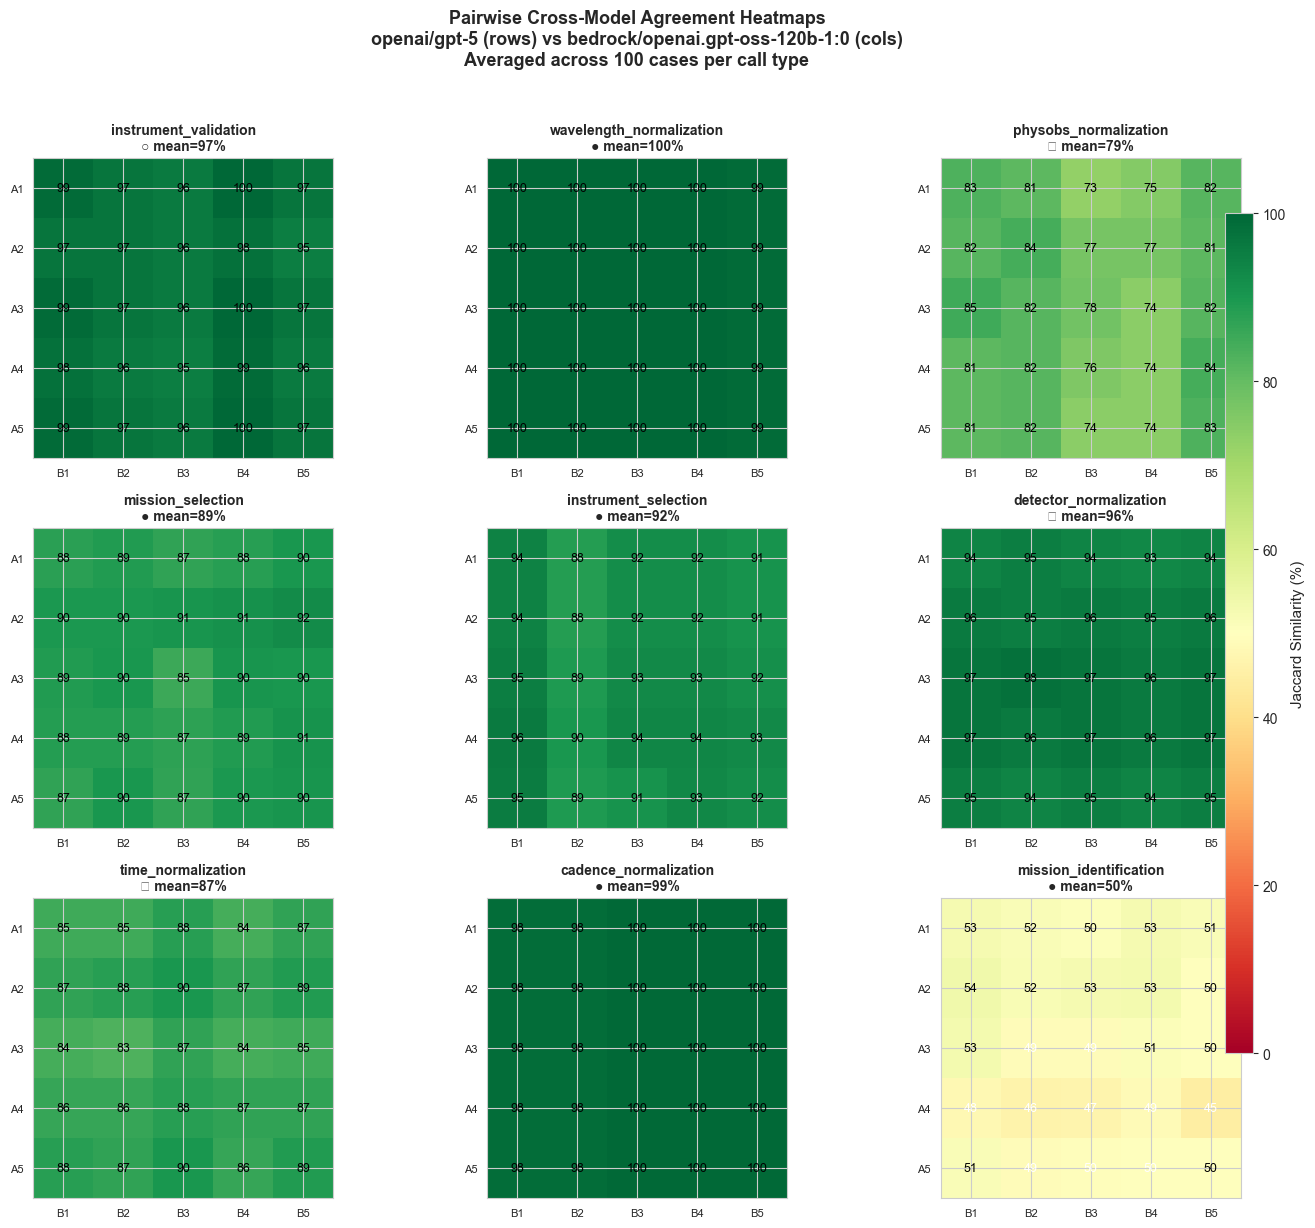


Interpretation:
- Each cell shows mean Jaccard between run i of Model A and run j of Model B
- Uniform heatmap = consistent agreement regardless of which run is sampled
- Patchy heatmap = agreement depends heavily on which specific runs are compared
- Diagonal vs off-diagonal patterns could indicate run-order effects (unlikely with temp=1.0)


In [15]:
# Heatmap of all pairwise comparisons
# Shows the full 5×5 matrix of run comparisons, averaged across all cases

fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.flatten()

for idx, call_type in enumerate(CALL_TYPES):
    ax = axes[idx]
    
    # Get the response sets for both models
    model1, model2 = MODELS[0], MODELS[1]
    cases1 = all_results[model1][call_type]['cases']
    cases2 = all_results[model2][call_type]['cases']
    
    # Build average 5×5 pairwise matrix
    pairwise_matrix = np.zeros((NUM_RUNS, NUM_RUNS))
    n_cases = 0
    
    common_cases = set(cases1.keys()) & set(cases2.keys())
    for case_id in common_cases:
        sets1 = cases1[case_id].get('response_sets', [])
        sets2 = cases2[case_id].get('response_sets', [])
        
        if len(sets1) == NUM_RUNS and len(sets2) == NUM_RUNS:
            for i in range(NUM_RUNS):
                for j in range(NUM_RUNS):
                    pairwise_matrix[i, j] += jaccard_similarity(sets1[i], sets2[j])
            n_cases += 1
    
    if n_cases > 0:
        pairwise_matrix /= n_cases
    
    # Plot heatmap
    im = ax.imshow(pairwise_matrix * 100, cmap='RdYlGn', vmin=0, vmax=100, aspect='equal')
    
    # Add text annotations
    for i in range(NUM_RUNS):
        for j in range(NUM_RUNS):
            val = pairwise_matrix[i, j] * 100
            color = 'white' if val < 50 else 'black'
            ax.text(j, i, f'{val:.0f}', ha='center', va='center', fontsize=9, color=color)
    
    # Labels
    ax.set_xticks(range(NUM_RUNS))
    ax.set_yticks(range(NUM_RUNS))
    ax.set_xticklabels([f'B{r+1}' for r in range(NUM_RUNS)], fontsize=8)
    ax.set_yticklabels([f'A{r+1}' for r in range(NUM_RUNS)], fontsize=8)
    
    # Title with mean
    mean_jaccard = np.mean(pairwise_matrix) * 100
    task_type = TASK_TYPES[call_type]
    marker = {'binary': '○', 'single': '◐', 'set': '●'}[task_type]
    ax.set_title(f'{call_type}\n{marker} mean={mean_jaccard:.0f}%', fontsize=10, fontweight='bold')

# Add colorbar
fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Jaccard Similarity (%)', fontsize=11)

# Overall title
fig.suptitle(f'Pairwise Cross-Model Agreement Heatmaps\n{MODELS[0]} (rows) vs {MODELS[1]} (cols)\nAveraged across {n_cases} cases per call type', 
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- Each cell shows mean Jaccard between run i of Model A and run j of Model B")
print("- Uniform heatmap = consistent agreement regardless of which run is sampled")
print("- Patchy heatmap = agreement depends heavily on which specific runs are compared")
print("- Diagonal vs off-diagonal patterns could indicate run-order effects (unlikely with temp=1.0)")

/var/folders/h9/nw8szmz14h90jhkl81qgp1080000gp/T/ipykernel_51326/3776981854.py:49: UserWarning: Glyph 9680 (\N{CIRCLE WITH LEFT HALF BLACK}) missing from font(s) Arial.
  plt.tight_layout()


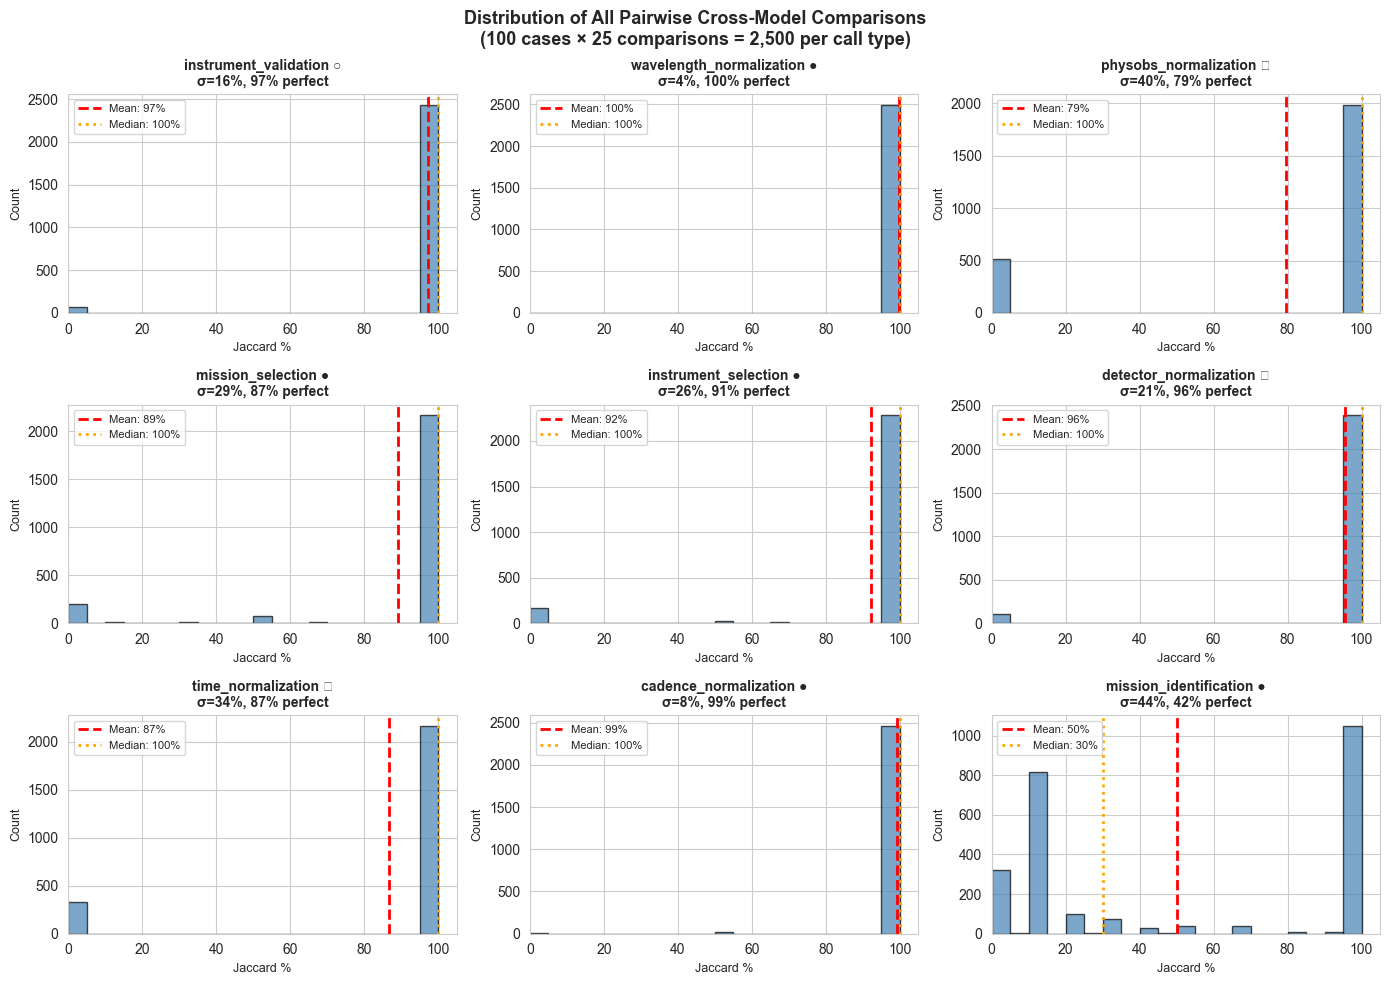


What to look for:
- Bimodal distribution (peaks at 0% and 100%) = binary agreement (all-or-nothing)
- Right-skewed with peak near 100% = mostly agree with some outliers
- Wide spread = high variance, agreement depends heavily on specific runs
- Narrow peak = consistent agreement regardless of which runs are compared


In [16]:
# Distribution of ALL pairwise Jaccard comparisons per call type
# Shows the full spread, not just the mean

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for idx, call_type in enumerate(CALL_TYPES):
    ax = axes[idx]
    
    # Get all pairwise Jaccards from cross_model_results
    result = list(cross_model_results[call_type].values())[0]
    all_jaccards = result.get('all_pairwise_jaccards', [])
    
    if all_jaccards:
        # Convert to percentage
        all_jaccards_pct = [j * 100 for j in all_jaccards]
        
        # Plot histogram
        ax.hist(all_jaccards_pct, bins=20, range=(0, 100), color='steelblue', 
                edgecolor='black', alpha=0.7)
        
        # Add mean line
        mean_val = np.mean(all_jaccards_pct)
        ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.0f}%')
        
        # Add median line
        median_val = np.median(all_jaccards_pct)
        ax.axvline(median_val, color='orange', linestyle=':', linewidth=2, label=f'Median: {median_val:.0f}%')
        
        # Stats
        std_val = np.std(all_jaccards_pct)
        n_perfect = sum(1 for j in all_jaccards_pct if j == 100)
        pct_perfect = n_perfect / len(all_jaccards_pct) * 100
        
        ax.legend(fontsize=8, loc='upper left')
        
        # Title
        task_type = TASK_TYPES[call_type]
        marker = {'binary': '○', 'single': '◐', 'set': '●'}[task_type]
        ax.set_title(f'{call_type} {marker}\nσ={std_val:.0f}%, {pct_perfect:.0f}% perfect', fontsize=10, fontweight='bold')
    
    ax.set_xlim(0, 105)
    ax.set_xlabel('Jaccard %', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)

fig.suptitle(f'Distribution of All Pairwise Cross-Model Comparisons\n(100 cases × 25 comparisons = 2,500 per call type)', 
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nWhat to look for:")
print("- Bimodal distribution (peaks at 0% and 100%) = binary agreement (all-or-nothing)")
print("- Right-skewed with peak near 100% = mostly agree with some outliers")  
print("- Wide spread = high variance, agreement depends heavily on specific runs")
print("- Narrow peak = consistent agreement regardless of which runs are compared")

/var/folders/h9/nw8szmz14h90jhkl81qgp1080000gp/T/ipykernel_51326/3763016892.py:39: UserWarning: Glyph 9680 (\N{CIRCLE WITH LEFT HALF BLACK}) missing from font(s) Arial.
  plt.tight_layout()
/Users/abuonomo/code/nasa/paper-data-linking/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9680 (\N{CIRCLE WITH LEFT HALF BLACK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


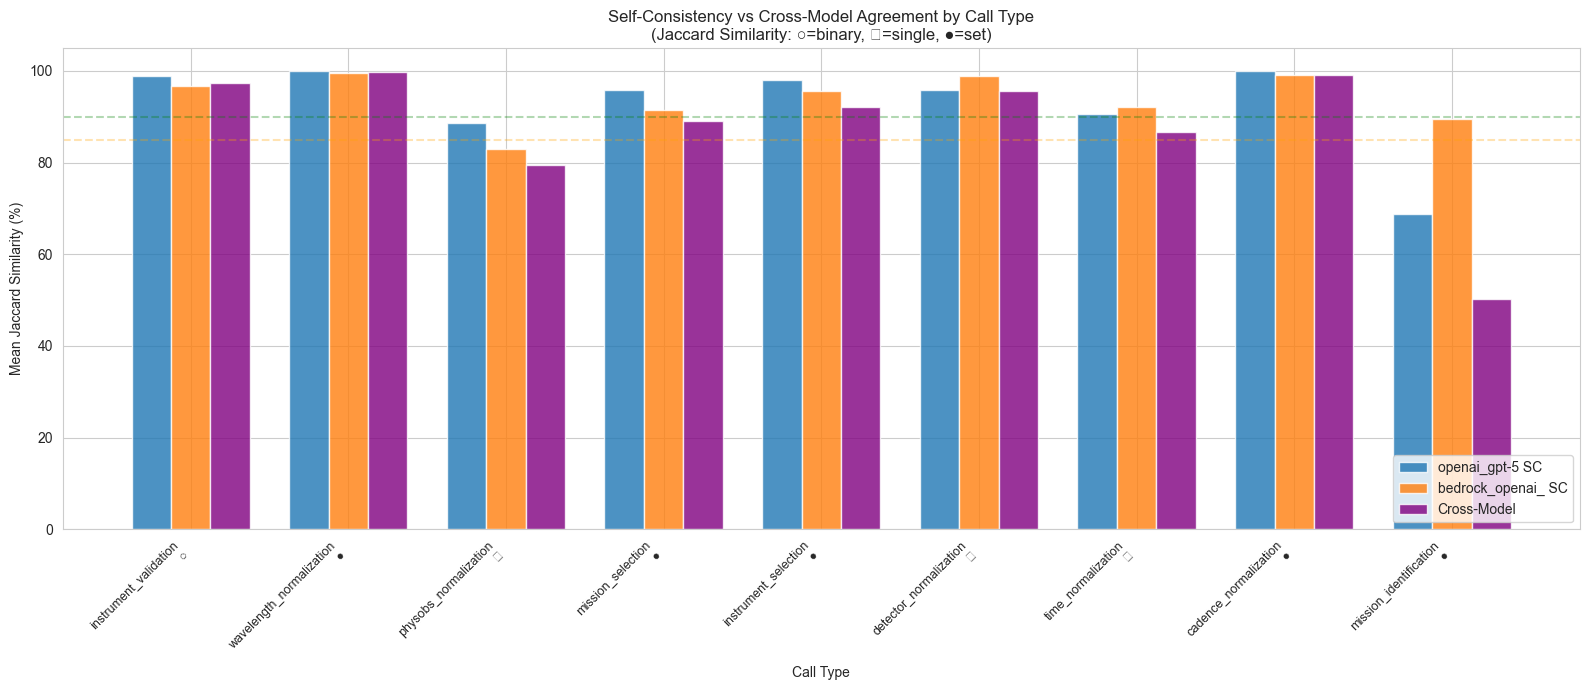

In [17]:
# Side-by-side bar chart with Jaccard metrics
fig, ax = plt.subplots(figsize=(16, 7))

x = range(len(CALL_TYPES))
width = 0.25

# Self-consistency bars (mean Jaccard) for each model
for i, model in enumerate(MODELS):
    rates = [all_results[model][ct]['mean_jaccard'] for ct in CALL_TYPES]
    ax.bar([xi + i * width for xi in x], rates, width, 
           label=f'{model_slug(model)[:15]} SC', alpha=0.8)

# Cross-model agreement bars (mean Jaccard)
cross_rates = []
for ct in CALL_TYPES:
    result = list(cross_model_results[ct].values())[0]
    cross_rates.append(result['mean_jaccard'] if result else 0)

ax.bar([xi + len(MODELS) * width for xi in x], cross_rates, width,
       label='Cross-Model', color='purple', alpha=0.8)

# Format x-axis labels with task type markers
task_labels = []
for ct in CALL_TYPES:
    task_type = TASK_TYPES[ct]
    marker = {'binary': '○', 'single': '◐', 'set': '●'}[task_type]
    task_labels.append(f"{ct}\n{marker}")

ax.set_xlabel('Call Type')
ax.set_ylabel('Mean Jaccard Similarity (%)')
ax.set_title('Self-Consistency vs Cross-Model Agreement by Call Type\n(Jaccard Similarity: ○=binary, ◐=single, ●=set)', fontsize=12)
ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels(task_labels, rotation=45, ha='right', fontsize=9)
ax.legend(loc='lower right')
ax.set_ylim(0, 105)
ax.axhline(y=90, color='green', linestyle='--', alpha=0.3, label='_nolegend_')
ax.axhline(y=85, color='orange', linestyle='--', alpha=0.3, label='_nolegend_')

plt.tight_layout()
plt.show()

## 7. Investigate Disagreements

In [18]:
# Select a call type to investigate
INVESTIGATE_CALL_TYPE = 'mission_identification'  # Change this

# Get cross-model result for this call type
result = list(cross_model_results[INVESTIGATE_CALL_TYPE].values())[0]
task_type = TASK_TYPES[INVESTIGATE_CALL_TYPE]

if result and result['disagreements']:
    print(f"\n{'='*80}")
    print(f"DISAGREEMENT ANALYSIS: {INVESTIGATE_CALL_TYPE} ({task_type} task)")
    print(f"{'='*80}")
    print(f"Mean Jaccard: {result['mean_jaccard']:.1f}%")
    print(f"Perfect Agreement: {result['perfect_rate']:.1f}% ({result['perfect_agree']}/{result['total']})")
    print(f"Cases with differences: {len(result['disagreements'])}\n")
    
    # Show worst 5 disagreements (lowest Jaccard)
    print("Worst disagreements (lowest Jaccard):")
    print("-" * 80)
    
    for i, case in enumerate(result['disagreements'][:5], 1):
        jaccard_pct = case['jaccard'] * 100
        print(f"\nCase {i}: {case['case_id'][:20]}...")
        print(f"  Jaccard: {jaccard_pct:.0f}%")
        print(f"  {MODELS[0][:20]}: {set(case['model1_set'])}")
        print(f"  {MODELS[1][:20]}: {set(case['model2_set'])}")
        
        # Show overlap analysis for set tasks
        if task_type == 'set':
            intersection = case['model1_set'] & case['model2_set']
            only_m1 = case['model1_set'] - case['model2_set']
            only_m2 = case['model2_set'] - case['model1_set']
            print(f"  Overlap: {len(intersection)} | Only {MODELS[0][:10]}: {len(only_m1)} | Only {MODELS[1][:10]}: {len(only_m2)}")
else:
    print(f"No disagreements for {INVESTIGATE_CALL_TYPE} - 100% agreement!")


DISAGREEMENT ANALYSIS: mission_identification (set task)
Mean Jaccard: 50.2%
Perfect Agreement: 22.0% (22/100)
Cases with differences: 78

Worst disagreements (lowest Jaccard):
--------------------------------------------------------------------------------

Case 1: da1b79d6-c54e-4065-9...
  Jaccard: 0%
  openai/gpt-5: {'37', '38', '34', '28', '11', '30', '36', '10', '9', '35'}
  bedrock/openai.gpt-o: set()
  Overlap: 0 | Only openai/gpt: 10 | Only bedrock/op: 0

Case 2: eddefdc3-184e-4411-a...
  Jaccard: 0%
  openai/gpt-5: {'323', '99', '311', '1', '275', '127', '312', '119', '307', '360'}
  bedrock/openai.gpt-o: set()
  Overlap: 0 | Only openai/gpt: 10 | Only bedrock/op: 0

Case 3: f3104a5e-f577-46f5-8...
  Jaccard: 0%
  openai/gpt-5: {'131', '122', '85', '86', '82', '271', '84', '110', '187', '80'}
  bedrock/openai.gpt-o: set()
  Overlap: 0 | Only openai/gpt: 10 | Only bedrock/op: 0

Case 4: 8c1e881f-c6c2-4970-b...
  Jaccard: 10%
  openai/gpt-5: {'131', '350', '311', '1', '86', '82

## Summary

This notebook analyzed cross-model agreement using **Jaccard similarity** as a unified metric.

### Methodology

**Jaccard Similarity** = |intersection| / |union|

- For **binary/single tasks**: Jaccard is 0 (different) or 1 (same) - equivalent to exact match
- For **set tasks**: Jaccard captures partial overlap (0 to 1) - more forgiving of minor differences

### Task Types

| Type | Symbol | Tasks | Behavior |
|------|--------|-------|----------|
| Binary | ○ | instrument_validation | Yes/No responses |
| Single | ◐ | detector, physobs, time_normalization | Single complex value |
| Set | ● | wavelength, cadence, mission/instrument selection/identification | Lists where partial overlap matters |

### Interpretation Guide

| Self-Consistency | Cross-Model | Status | Meaning |
|------------------|-------------|--------|---------|
| ≥90% | ≥85% | ✅ Robust | Task works well |
| ≥90% | <85% | ⚠️ Bias | Models interpret differently |
| <90% | <85% | ❌ Ambiguous | Task needs redesign |
| Mixed | Mixed | 📊 Moderate | Partial issues |

### Next Steps

1. Investigate tasks with systematic bias (high SC, low cross-model)
2. Consider prompt modifications for ambiguous tasks
3. For set tasks, examine which specific elements cause disagreement

## 8. Null Response Analysis

Many call types have "null-equivalent" responses where the model returns a non-answer (e.g., "UNCERTAIN", "not_applicable", empty list). These null responses can inflate cross-model agreement when both models return null together.

This section analyzes:
1. **Null response rates** per model and call type
2. **Impact on agreement**: How much do null responses inflate cross-model agreement?
3. **Non-null agreement**: What is the "true" agreement when both models actually answer?

In [19]:
# ============================================================================
# NULL DETECTION FUNCTIONS
# ============================================================================

def is_null_response(output_content: str, call_type: str) -> bool:
    """
    Determine if a response is effectively "null" (no meaningful answer).
    
    Each call type has different null patterns:
    - physobs_normalization: 'UNCERTAIN'
    - wavelength_normalization: 'not_applicable', 'none', 'null', ''
    - cadence_normalization: 'none', 'null', '', empty
    - detector_normalization: 'none', 'null', 'uncertain', '', empty
    - mission_identification: contains 'unknown', empty, '[]'
    - time_normalization: JSON with null/missing start_datetime and end_datetime
    - instrument_validation: boolean task, no null
    - mission_selection: 'none', 'null', 'unknown', empty
    - instrument_selection: 'none', 'null', empty
    """
    text = output_content.strip()
    text_lower = text.lower()

    if call_type == 'physobs_normalization':
        return text.upper() == 'UNCERTAIN'

    elif call_type == 'wavelength_normalization':
        return text_lower in ['not_applicable', 'none', 'null', 'n/a', '']

    elif call_type == 'cadence_normalization':
        return text_lower in ['none', 'null', 'n/a', ''] or text == ''

    elif call_type == 'detector_normalization':
        return text_lower in ['none', 'null', 'n/a', 'uncertain', ''] or text == ''

    elif call_type == 'mission_identification':
        return 'unknown' in text_lower or text == '' or text == '[]'

    elif call_type == 'time_normalization':
        try:
            data = json.loads(text)
            start = data.get('start_datetime')
            end = data.get('end_datetime')
            return (not start or start == 'null') and (not end or end == 'null')
        except:
            return text == '' or text_lower in ['none', 'null']

    elif call_type == 'instrument_validation':
        # Boolean task - no null equivalent
        return False

    elif call_type == 'mission_selection':
        return text_lower in ['none', 'null', 'unknown', ''] or text == '[]'

    elif call_type == 'instrument_selection':
        return text_lower in ['none', 'null', ''] or text == '[]'

    return False


def load_raw_outputs(model, call_type):
    """Load raw output content from all runs for a model/call_type."""
    slug = model_slug(model)
    outputs = defaultdict(list)  # case_id -> [output1, output2, ...]
    
    for run in range(1, NUM_RUNS + 1):
        exp_dir = RESULTS_DIR / TEST_SET_TAG / slug / call_type / f"run{run}"
        jsonl_files = list(exp_dir.glob('*.jsonl'))
        
        if not jsonl_files:
            continue
        
        with open(jsonl_files[0]) as f:
            for line in f:
                data = json.loads(line)
                case_id = data.get('original_id', data.get('case_index'))
                output_content = data.get('output_content', '')
                outputs[case_id].append(output_content)
    
    return dict(outputs)


print("Null detection functions defined.")

Null detection functions defined.


In [20]:
# ============================================================================
# COMPUTE NULL RATES AND NON-NULL AGREEMENT
# ============================================================================

null_analysis_results = []

for call_type in CALL_TYPES:
    # Load raw outputs for both models
    model1, model2 = MODELS[0], MODELS[1]
    outputs1 = load_raw_outputs(model1, call_type)
    outputs2 = load_raw_outputs(model2, call_type)
    
    common_cases = set(outputs1.keys()) & set(outputs2.keys())
    
    # Count nulls per model (across all runs)
    m1_null_runs = 0
    m1_total_runs = 0
    m2_null_runs = 0
    m2_total_runs = 0
    
    # Track pairwise null patterns
    both_null_pairs = 0
    any_null_pairs = 0
    total_pairs = 0
    
    # Agreement metrics
    jaccards_all = []
    jaccards_non_null = []
    
    for case_id in common_cases:
        runs1 = outputs1[case_id]
        runs2 = outputs2[case_id]
        
        # Count nulls per model
        for out in runs1:
            m1_total_runs += 1
            if is_null_response(out, call_type):
                m1_null_runs += 1
        
        for out in runs2:
            m2_total_runs += 1
            if is_null_response(out, call_type):
                m2_null_runs += 1
        
        # Get response sets for Jaccard (from pre-loaded results)
        sets1 = all_results[model1][call_type]['cases'][case_id].get('response_sets', [])
        sets2 = all_results[model2][call_type]['cases'][case_id].get('response_sets', [])
        
        # Pairwise comparisons with null tracking
        for i, (out1, s1) in enumerate(zip(runs1, sets1)):
            for j, (out2, s2) in enumerate(zip(runs2, sets2)):
                total_pairs += 1
                
                is_null_1 = is_null_response(out1, call_type)
                is_null_2 = is_null_response(out2, call_type)
                
                jac = jaccard_similarity(s1, s2)
                jaccards_all.append(jac)
                
                if is_null_1 and is_null_2:
                    both_null_pairs += 1
                if is_null_1 or is_null_2:
                    any_null_pairs += 1
                else:
                    jaccards_non_null.append(jac)
    
    # Compute summary metrics
    m1_null_pct = m1_null_runs / m1_total_runs * 100 if m1_total_runs > 0 else 0
    m2_null_pct = m2_null_runs / m2_total_runs * 100 if m2_total_runs > 0 else 0
    both_null_pct = both_null_pairs / total_pairs * 100 if total_pairs > 0 else 0
    
    mean_jac_all = np.mean(jaccards_all) * 100 if jaccards_all else 0
    mean_jac_non_null = np.mean(jaccards_non_null) * 100 if jaccards_non_null else np.nan
    
    # How much agreement is inflated by nulls
    inflation = mean_jac_all - mean_jac_non_null if jaccards_non_null else 0
    
    null_analysis_results.append({
        'call_type': call_type,
        'task_type': TASK_TYPES[call_type],
        'm1_null_pct': m1_null_pct,
        'm2_null_pct': m2_null_pct,
        'both_null_pct': both_null_pct,
        'any_null_pct': any_null_pairs / total_pairs * 100 if total_pairs > 0 else 0,
        'agreement_all': mean_jac_all,
        'agreement_non_null': mean_jac_non_null,
        'inflation': inflation,
        'n_non_null_pairs': len(jaccards_non_null),
        'n_total_pairs': total_pairs,
    })

df_null = pd.DataFrame(null_analysis_results)

# Display results
print("="*120)
print("NULL RESPONSE ANALYSIS")
print("="*120)
print(f"\n{'Call Type':<28} {'GPT-5 Null':>12} {'Bedrock Null':>14} {'Both Null':>12} {'Agree (All)':>12} {'Agree (Non-null)':>17} {'Δ':>8}")
print("-"*120)

for _, row in df_null.sort_values('inflation', ascending=False).iterrows():
    nn_str = f"{row['agreement_non_null']:.1f}%" if not np.isnan(row['agreement_non_null']) else "N/A"
    delta_str = f"{row['inflation']:+.1f}%" if not np.isnan(row['agreement_non_null']) else "N/A"
    print(f"{row['call_type']:<28} {row['m1_null_pct']:>11.1f}% {row['m2_null_pct']:>13.1f}% {row['both_null_pct']:>11.1f}% {row['agreement_all']:>11.1f}% {nn_str:>16} {delta_str:>8}")

print("\n" + "="*120)
print("Interpretation:")
print("  - Δ > 0: Null responses INFLATE agreement (both models return null together)")
print("  - Δ < 0: Null responses DEFLATE agreement (models disagree on when to return null)")
print("  - Agree (Non-null): Agreement when BOTH models return actual answers")
print("="*120)

NULL RESPONSE ANALYSIS

Call Type                      GPT-5 Null   Bedrock Null    Both Null  Agree (All)  Agree (Non-null)        Δ
------------------------------------------------------------------------------------------------------------------------
mission_identification              31.2%          40.8%        29.6%        50.2%            35.7%   +14.5%
cadence_normalization               84.0%          83.8%        83.8%        99.1%            95.6%    +3.5%
wavelength_normalization            43.6%          45.0%        43.6%        99.8%            99.6%    +0.2%
instrument_validation                0.0%           0.0%         0.0%        97.4%            97.4%    +0.0%
mission_selection                    0.0%           0.0%         0.0%        89.1%            89.1%    +0.0%
instrument_selection                 0.0%           0.0%         0.0%        92.1%            92.1%    +0.0%
time_normalization                   1.0%           2.0%         0.0%        86.7%         

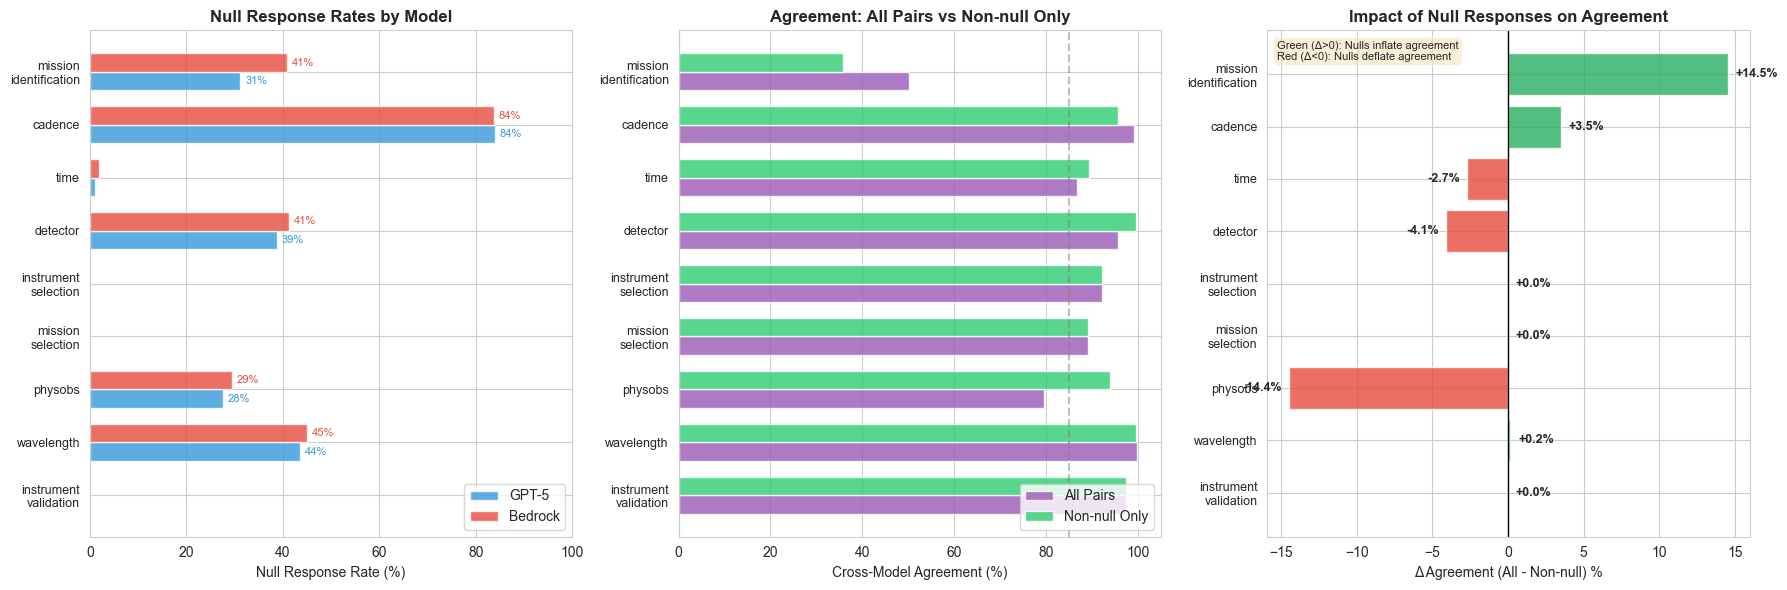


Key Findings:
--------------------------------------------------------------------------------
• mission_identification: Agreement drops 14% when excluding nulls (50% → 36%)
• cadence_normalization: 84% of pairs are both-null, masking real disagreement
• physobs_normalization: Models disagree on WHEN to return null, not WHAT value
• instrument_validation, mission_selection: No null responses, agreement unchanged


In [21]:
# ============================================================================
# VISUALIZATION: NULL RESPONSE RATES BY MODEL AND CALL TYPE
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Null rates by model (grouped bar chart)
ax1 = axes[0]
x = np.arange(len(CALL_TYPES))
width = 0.35

m1_nulls = [df_null[df_null['call_type'] == ct]['m1_null_pct'].values[0] for ct in CALL_TYPES]
m2_nulls = [df_null[df_null['call_type'] == ct]['m2_null_pct'].values[0] for ct in CALL_TYPES]

bars1 = ax1.barh(x - width/2, m1_nulls, width, label='GPT-5', color='#3498db', alpha=0.8)
bars2 = ax1.barh(x + width/2, m2_nulls, width, label='Bedrock', color='#e74c3c', alpha=0.8)

ax1.set_yticks(x)
ax1.set_yticklabels([ct.replace('_normalization', '').replace('_', '\n') for ct in CALL_TYPES], fontsize=9)
ax1.set_xlabel('Null Response Rate (%)')
ax1.set_title('Null Response Rates by Model', fontweight='bold')
ax1.legend(loc='lower right')
ax1.set_xlim(0, 100)

# Add value labels
for bar, val in zip(bars1, m1_nulls):
    if val > 5:
        ax1.text(val + 1, bar.get_y() + bar.get_height()/2, f'{val:.0f}%', 
                 va='center', fontsize=8, color='#3498db')
for bar, val in zip(bars2, m2_nulls):
    if val > 5:
        ax1.text(val + 1, bar.get_y() + bar.get_height()/2, f'{val:.0f}%', 
                 va='center', fontsize=8, color='#e74c3c')

# 2. Agreement comparison: All vs Non-null
ax2 = axes[1]
agree_all = [df_null[df_null['call_type'] == ct]['agreement_all'].values[0] for ct in CALL_TYPES]
agree_nn = [df_null[df_null['call_type'] == ct]['agreement_non_null'].values[0] for ct in CALL_TYPES]

# Handle NaN values
agree_nn_clean = [v if not np.isnan(v) else 0 for v in agree_nn]

bars1 = ax2.barh(x - width/2, agree_all, width, label='All Pairs', color='#9b59b6', alpha=0.8)
bars2 = ax2.barh(x + width/2, agree_nn_clean, width, label='Non-null Only', color='#2ecc71', alpha=0.8)

ax2.set_yticks(x)
ax2.set_yticklabels([ct.replace('_normalization', '').replace('_', '\n') for ct in CALL_TYPES], fontsize=9)
ax2.set_xlabel('Cross-Model Agreement (%)')
ax2.set_title('Agreement: All Pairs vs Non-null Only', fontweight='bold')
ax2.legend(loc='lower right')
ax2.set_xlim(0, 105)
ax2.axvline(x=85, color='gray', linestyle='--', alpha=0.5)

# 3. Inflation/Deflation bar chart
ax3 = axes[2]
inflation = [df_null[df_null['call_type'] == ct]['inflation'].values[0] for ct in CALL_TYPES]
inflation_clean = [v if not np.isnan(v) else 0 for v in inflation]
colors = ['#27ae60' if v > 0 else '#e74c3c' for v in inflation_clean]

bars = ax3.barh(x, inflation_clean, color=colors, alpha=0.8)
ax3.set_yticks(x)
ax3.set_yticklabels([ct.replace('_normalization', '').replace('_', '\n') for ct in CALL_TYPES], fontsize=9)
ax3.set_xlabel('Δ Agreement (All - Non-null) %')
ax3.set_title('Impact of Null Responses on Agreement', fontweight='bold')
ax3.axvline(x=0, color='black', linestyle='-', linewidth=1)

# Add value labels
for bar, val in zip(bars, inflation_clean):
    x_pos = val + 0.5 if val >= 0 else val - 0.5
    ha = 'left' if val >= 0 else 'right'
    ax3.text(x_pos, bar.get_y() + bar.get_height()/2, f'{val:+.1f}%', 
             va='center', ha=ha, fontsize=9, fontweight='bold')

# Add interpretation
ax3.text(0.02, 0.98, 'Green (Δ>0): Nulls inflate agreement\nRed (Δ<0): Nulls deflate agreement', 
         transform=ax3.transAxes, fontsize=8, va='top', 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("\nKey Findings:")
print("-" * 80)
print("• mission_identification: Agreement drops 14% when excluding nulls (50% → 36%)")
print("• cadence_normalization: 84% of pairs are both-null, masking real disagreement")
print("• physobs_normalization: Models disagree on WHEN to return null, not WHAT value")
print("• instrument_validation, mission_selection: No null responses, agreement unchanged")

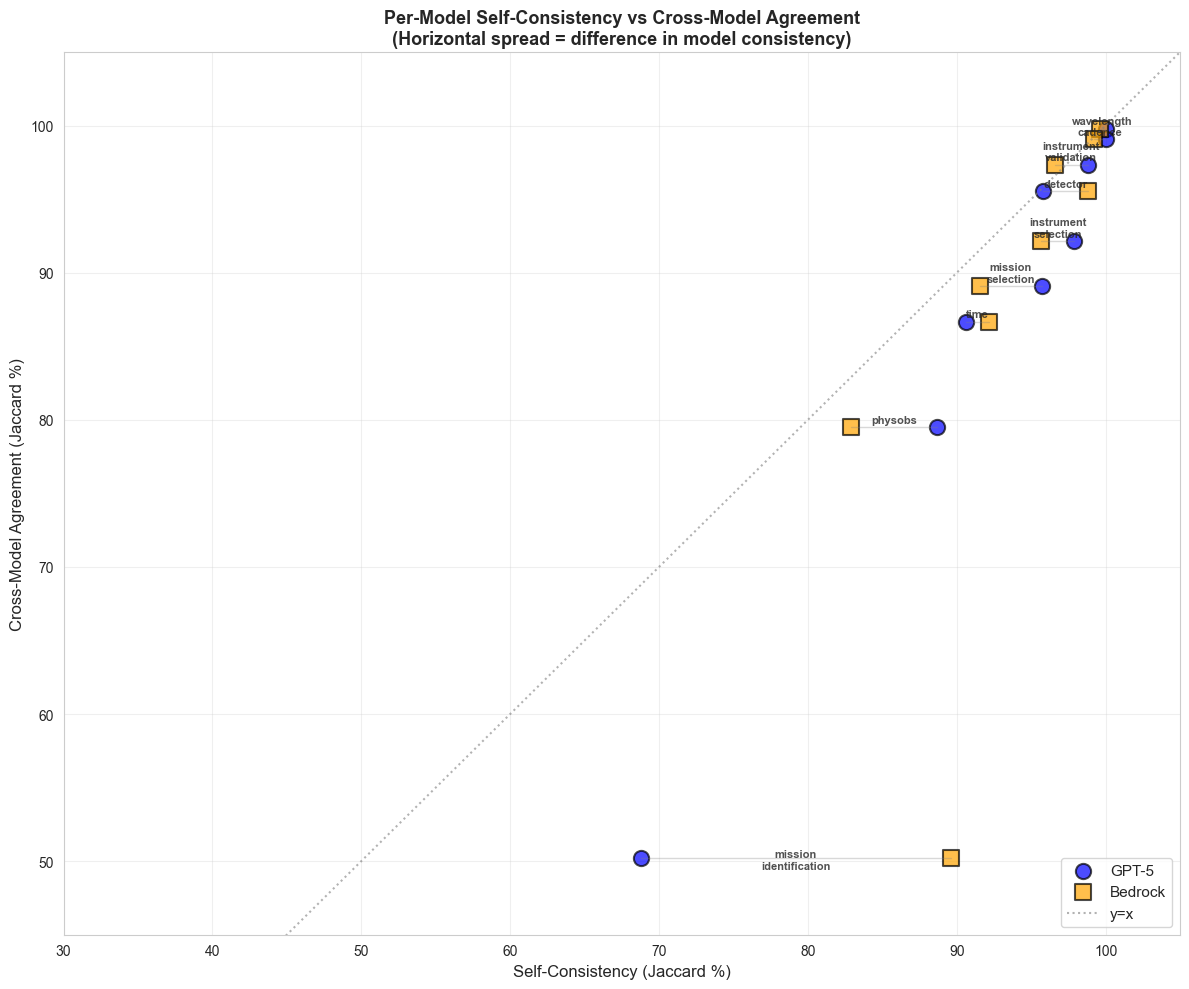


MODEL SELF-CONSISTENCY COMPARISON
Call Type                    GPT-5 SC     Bedrock SC   Delta      Cross     
------------------------------------------------------------------------------------------
mission_identification             68.8%       89.6%    -20.8%     50.2%  (Bedrock)
detector_normalization             95.8%       98.8%     -3.0%     95.6%  (Bedrock)
time_normalization                 90.6%       92.2%     -1.6%     86.7%  (~same)
wavelength_normalization          100.0%       99.6%     +0.4%     99.8%  (~same)
cadence_normalization             100.0%       99.2%     +0.8%     99.1%  (~same)
instrument_validation              98.8%       96.6%     +2.2%     97.4%  (GPT-5)
instrument_selection               97.9%       95.7%     +2.2%     92.1%  (GPT-5)
mission_selection                  95.7%       91.6%     +4.2%     89.1%  (GPT-5)
physobs_normalization              88.7%       82.9%     +5.8%     79.5%  (GPT-5)


In [22]:
# Per-Model Self-Consistency vs Cross-Model Agreement
# Shows what we lose by averaging: which model is more consistent on each task

fig, ax = plt.subplots(figsize=(12, 10))

# Compute per-model self-consistency
per_model_data = []
for call_type in CALL_TYPES:
    task_type = TASK_TYPES[call_type]
    cross_result = list(cross_model_results[call_type].values())[0]
    cross_jaccard = cross_result['mean_jaccard'] if cross_result else 0
    
    for model in MODELS:
        model_result = all_results[model][call_type]
        sc = model_result['mean_jaccard']
        model_label = 'GPT-5' if 'gpt-5' in model and 'gpt-oss' not in model else 'Bedrock'
        
        per_model_data.append({
            'call_type': call_type,
            'model': model_label,
            'self_consistency': sc,
            'cross_model': cross_jaccard,
            'task_type': task_type,
        })

df_per_model = pd.DataFrame(per_model_data)

# Plot settings
colors = {'GPT-5': 'blue', 'Bedrock': 'orange'}
markers = {'GPT-5': 'o', 'Bedrock': 's'}

# Plot each model separately
for model in ['GPT-5', 'Bedrock']:
    subset = df_per_model[df_per_model['model'] == model]
    ax.scatter(
        subset['self_consistency'], 
        subset['cross_model'],
        c=colors[model],
        marker=markers[model],
        s=120,
        alpha=0.7,
        edgecolors='black',
        linewidths=1.5,
        label=model,
    )

# Add diagonal y=x line
ax.plot([30, 105], [30, 105], color='gray', linestyle=':', alpha=0.6, linewidth=1.5, label='y=x')

# Connect same call_types with lines to show the spread
for call_type in CALL_TYPES:
    subset = df_per_model[df_per_model['call_type'] == call_type]
    if len(subset) == 2:
        x_vals = subset['self_consistency'].values
        y_val = subset['cross_model'].values[0]  # Same for both
        ax.plot(x_vals, [y_val, y_val], color='gray', alpha=0.3, linewidth=1)

# Add labels for each call type (at midpoint)
for call_type in CALL_TYPES:
    subset = df_per_model[df_per_model['call_type'] == call_type]
    x_mid = subset['self_consistency'].mean()
    y_val = subset['cross_model'].values[0]
    label = call_type.replace('_normalization', '').replace('_', '\n')
    
    # Offset labels to avoid overlap
    y_offset = 3 if y_val > 60 else -8
    ax.annotate(
        label, (x_mid, y_val),
        textcoords="offset points", 
        xytext=(0, y_offset), 
        ha='center', 
        fontsize=8,
        fontweight='bold',
        alpha=0.8,
    )

ax.set_xlim(30, 105)
ax.set_ylim(45, 105)
ax.set_xlabel('Self-Consistency (Jaccard %)', fontsize=12)
ax.set_ylabel('Cross-Model Agreement (Jaccard %)', fontsize=12)
ax.set_title('Per-Model Self-Consistency vs Cross-Model Agreement\n(Horizontal spread = difference in model consistency)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary of model differences
print("\n" + "="*90)
print("MODEL SELF-CONSISTENCY COMPARISON")
print("="*90)
print(f"{'Call Type':<28} {'GPT-5 SC':<12} {'Bedrock SC':<12} {'Delta':<10} {'Cross':<10}")
print("-"*90)
for call_type in sorted(CALL_TYPES, key=lambda ct: df_per_model[(df_per_model['call_type']==ct) & (df_per_model['model']=='GPT-5')]['self_consistency'].values[0] - df_per_model[(df_per_model['call_type']==ct) & (df_per_model['model']=='Bedrock')]['self_consistency'].values[0]):
    gpt5_sc = df_per_model[(df_per_model['call_type']==call_type) & (df_per_model['model']=='GPT-5')]['self_consistency'].values[0]
    bedrock_sc = df_per_model[(df_per_model['call_type']==call_type) & (df_per_model['model']=='Bedrock')]['self_consistency'].values[0]
    cross = df_per_model[df_per_model['call_type']==call_type]['cross_model'].values[0]
    delta = gpt5_sc - bedrock_sc
    winner = "GPT-5" if delta > 2 else "Bedrock" if delta < -2 else "~same"
    print(f"{call_type:<28} {gpt5_sc:>10.1f}% {bedrock_sc:>10.1f}% {delta:>+8.1f}% {cross:>8.1f}%  ({winner})")